# 差分面积法筛选 (CN differential-area screening)

独立方法二：候选光谱相对簇内正常参考光谱的逐波长残差面积。正常参考采用 leave-one-out 构建，避免自包含。与方法一共享同一套参考池构造。主筛选同样为 CN3839 与 CN4142 残差面积相对 z 同时 ≥ 1.0；1.5/2.0/2.5σ 并行分级。CH4300 面积只用于标记 CH 类别。

## 1. 环境与输入边界

同指数法：解释器固定为 `myenv`，候选成员权威来源与分数补充规则一致。

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "feature" else NOTEBOOK_DIR
for p in (str(NOTEBOOK_DIR), str(PROJECT_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)

import cn_common as cc
import cn_area_screening as ca

print("python:", sys.executable)
print("notebook dir:", NOTEBOOK_DIR)

python: D:\Anaconda\envs\myenv\python.exe
notebook dir: D:\资料\2026大创\Lamost\feature


## 2. 冻结候选输入与 UID 一致性

In [2]:
inputs = cc.load_and_validate_inputs()
print("candidate rows:", len(inputs.candidates))
print("unique uids:", inputs.candidates["uid"].nunique())
display(inputs.candidates.head())
assert len(inputs.candidates) == 654

candidate rows: 654
unique uids: 654


,uid,ra,dec,teff,logg,feh,label,snru,xgb_pu_std,masked_cluster_id,xgb_pu_score
0,G14417857215136,258.532204,26.890513,4485.02,0.905,-1.557,-1,38.88,0.005412,34,0.984312
1,G14115435813304,319.932960,18.358957,4920.05,2.255,-1.243,-1,60.95,0.005783,34,0.983672
2,G15801615940186,104.362394,55.719890,4437.85,0.890,-1.783,-1,45.54,0.024899,31,0.983298
3,G14866615886127,191.659997,7.423810,4904.80,1.935,-1.957,-1,49.10,0.035279,25,0.982810
4,G14502126087737,248.593692,23.235639,4956.85,2.472,-0.984,-1,14.73,0.029914,9,0.982755


## 3. DR13-all 缓存与母样本

In [3]:
cache = cc.load_cache()
print("X_clean:", cache["X_clean"].shape)
n_known = int((cache["stars_clean"]["label"] == 1).sum())
print("known CN:", n_known)
assert n_known == 91

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91
X_clean: (41243, 700)
known CN: 91


## 4. 执行差分面积法（计算 → 筛选 → 导出）

`run_area_screening` 构建簇内正常参考与 leave-one-out 正常面积分布，计算候选残差面积与显著性，写入 `feature/results_area/` 下三类文件。

In [4]:
res = ca.run_area_screening(output_dir=cc.RESULTS_AREA_DIR, verbose=True)
cand_df = res["candidates"]
known_df = res["known"]
print("candidate feature rows:", len(cand_df))
print("known feature rows:", len(known_df))
assert len(cand_df) == 654 and len(known_df) == 91

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91


  targets: candidates=654, known CN=91, normal refs=30128


  leave-one-out normal area: 2000/30128


  leave-one-out normal area: 4000/30128


  leave-one-out normal area: 6000/30128


...

  leave-one-out normal area: 24000/30128


  leave-one-out normal area: 26000/30128


  leave-one-out normal area: 28000/30128


  leave-one-out normal area: 30000/30128


[area] candidates=654  known=91
  tier>=1p0: candidates=147  known_recall=0.374 (n_pass=34)
  tier>=1p5: candidates=79  known_recall=0.187 (n_pass=17)
  tier>=2p0: candidates=25  known_recall=0.110 (n_pass=10)
  tier>=2p5: candidates=12  known_recall=0.077 (n_pass=7)
[area] wrote cn_area_candidates.csv, top30_area_candidates.png, cn_area_summary.json
candidate feature rows: 654
known feature rows: 91


## 5. 多阶段分级与已知 CN 召回

In [5]:
for label in ("1p0", "1p5", "2p0", "2p5"):
    c = int(cand_df[f"grade_{label}"].sum())
    k = float(known_df[f"grade_{label}"].mean())
    print(f"tier>={label}: candidates={c}  known_recall={k:.3f} (n_pass={int(known_df[f'grade_{label}'].sum())}/{len(known_df)})")
print("CH class (candidates):")
display(cand_df["ch_class"].value_counts(dropna=False))

tier>=1p0: candidates=147  known_recall=0.374 (n_pass=34/91)
tier>=1p5: candidates=79  known_recall=0.187 (n_pass=17/91)
tier>=2p0: candidates=25  known_recall=0.110 (n_pass=10/91)
tier>=2p5: candidates=12  known_recall=0.077 (n_pass=7/91)
CH class (candidates):


ch_class
ambiguous         507
CH-normal-like    138
CH-strong-like      9
Name: count, dtype: int64

## 6. 候选星示例（主筛选 ≥1σ，按 XGB 分数排序）

In [6]:
cols = ["uid", "xgb_pu_score", "teff", "logg", "feh", "snru", "masked_cluster_id",
        "area_cn3839_relative", "area_cn4142_relative", "area_ch4300_relative",
        "area_cn3839_z", "area_cn4142_z", "area_ch4300_z",
        "area_cn3839_signed", "area_cn4142_signed", "grade_1p0", "grade_2p0", "ch_class",
        "n_reference_members", "reference_quality"]
display(cand_df[cand_df["grade_1p0"]][cols].sort_values("xgb_pu_score", ascending=False).head(15))

,uid,xgb_pu_score,teff,logg,feh,snru,masked_cluster_id,area_cn3839_relative,area_cn4142_relative,area_ch4300_relative,area_cn3839_z,area_cn4142_z,area_ch4300_z,area_cn3839_signed,area_cn4142_signed,grade_1p0,grade_2p0,ch_class,n_reference_members,reference_quality
0,G14417857215136,0.984312,4485.02,0.905,-1.557,38.88,34,0.094901,0.020542,-0.010539,2.111446,1.708768,-0.376534,0.084032,0.020291,True,False,CH-normal-like,50,good
3,G14866615886127,0.982810,4904.80,1.935,-1.957,49.10,25,0.263206,0.024464,-0.093369,2.073076,2.625215,-2.748951,0.225461,0.024266,True,True,CH-normal-like,50,good
4,G14502126087737,0.982755,4956.85,2.472,-0.984,14.73,9,0.240923,0.015839,-0.030784,4.809725,1.989539,-2.143322,0.204771,0.015732,True,False,CH-normal-like,50,good
8,L14327934924837,0.980989,4504.52,1.026,-1.868,22.75,20,0.159835,0.023037,0.002088,4.434887,1.762025,0.285262,0.148429,0.023082,True,False,CH-normal-like,50,good
10,G16369423799359,0.979764,4428.72,0.932,-1.744,17.60,9,0.071620,0.017103,-0.066874,1.518462,1.388406,-2.973434,0.060437,0.017763,True,False,CH-normal-like,50,good
11,L15968094080310,0.979667,4773.54,1.877,-1.065,6.13,7,0.237773,0.028877,-0.051468,5.354217,3.204160,-3.528181,0.189326,0.029078,True,True,CH-normal-like,50,good
13,L14341383656115,0.978208,5107.44,2.500,-1.343,25.71,20,0.115604,0.018194,-0.056506,1.860723,1.991299,-2.304438,0.110020,0.018455,True,False,CH-normal-like,50,good
19,G13889826793626,0.974985,4839.70,2.031,-1.207,7.91,34,0.123747,0.024438,-0.041616,2.452607,1.670115,-1.441231,0.114298,0.024164,True,False,CH-normal-like,50,good
20,G15263068931183,0.974651,4781.49,2.369,-0.831,9.84,7,0.176906,0.011042,-0.036732,3.079557,1.363706,-3.455707,0.153717,0.012201,True,False,CH-normal-like,50,good
21,L15633295607629,0.974266,4938.72,2.380,-1.032,82.57,9,0.158151,0.011653,-0.010442,3.189857,1.602662,-0.685443,0.133060,0.011910,True,False,CH-normal-like,50,good


## 7. 导出文件、摘要与 Top30 光谱图

In [7]:
print("written files:")
for key, path in res["paths"].items():
    print(f"  {key}: {path}")
summary = json.loads(Path(res["paths"]["summary"]).read_text(encoding="utf-8"))
print(json.dumps({
    "candidate_count": summary["candidate_count"],
    "reference_quality": summary["reference_quality"],
    "tier_counts": summary["tier_counts"],
    "known_recall": summary["known_recall"],
    "primary_screening": summary["primary_screening"],
    "limitations": summary["limitations"],
}, ensure_ascii=False, indent=2))

written files:
  candidates: D:\资料\2026大创\Lamost\feature\results_area\cn_area_candidates.csv
  plot: D:\资料\2026大创\Lamost\feature\results_area\top30_area_candidates.png
  summary: D:\资料\2026大创\Lamost\feature\results_area\cn_area_summary.json
{
  "candidate_count": 654,
  "reference_quality": {
    "good": 653,
    "descriptive_only": 1
  },
  "tier_counts": {
    "1p0": {
      "candidate_cn_dual_pass": 147,
      "candidate_cn_dual_pass_robust": 222
    },
    "1p5": {
      "candidate_cn_dual_pass": 79,
      "candidate_cn_dual_pass_robust": 149
    },
    "2p0": {
      "candidate_cn_dual_pass": 25,
      "candidate_cn_dual_pass_robust": 76
    },
    "2p5": {
      "candidate_cn_dual_pass": 12,
      "candidate_cn_dual_pass_robust": 39
    }
  },
  "known_recall": {
    "1p0": {
      "recall": 0.37362637362637363,
      "n_pass": 34,
      "recall_robust": 0.5494505494505495,
      "n_pass_robust": 50
    },
    "1p5": {
      "recall": 0.18681318681318682,
      "n_pass": 17,
    

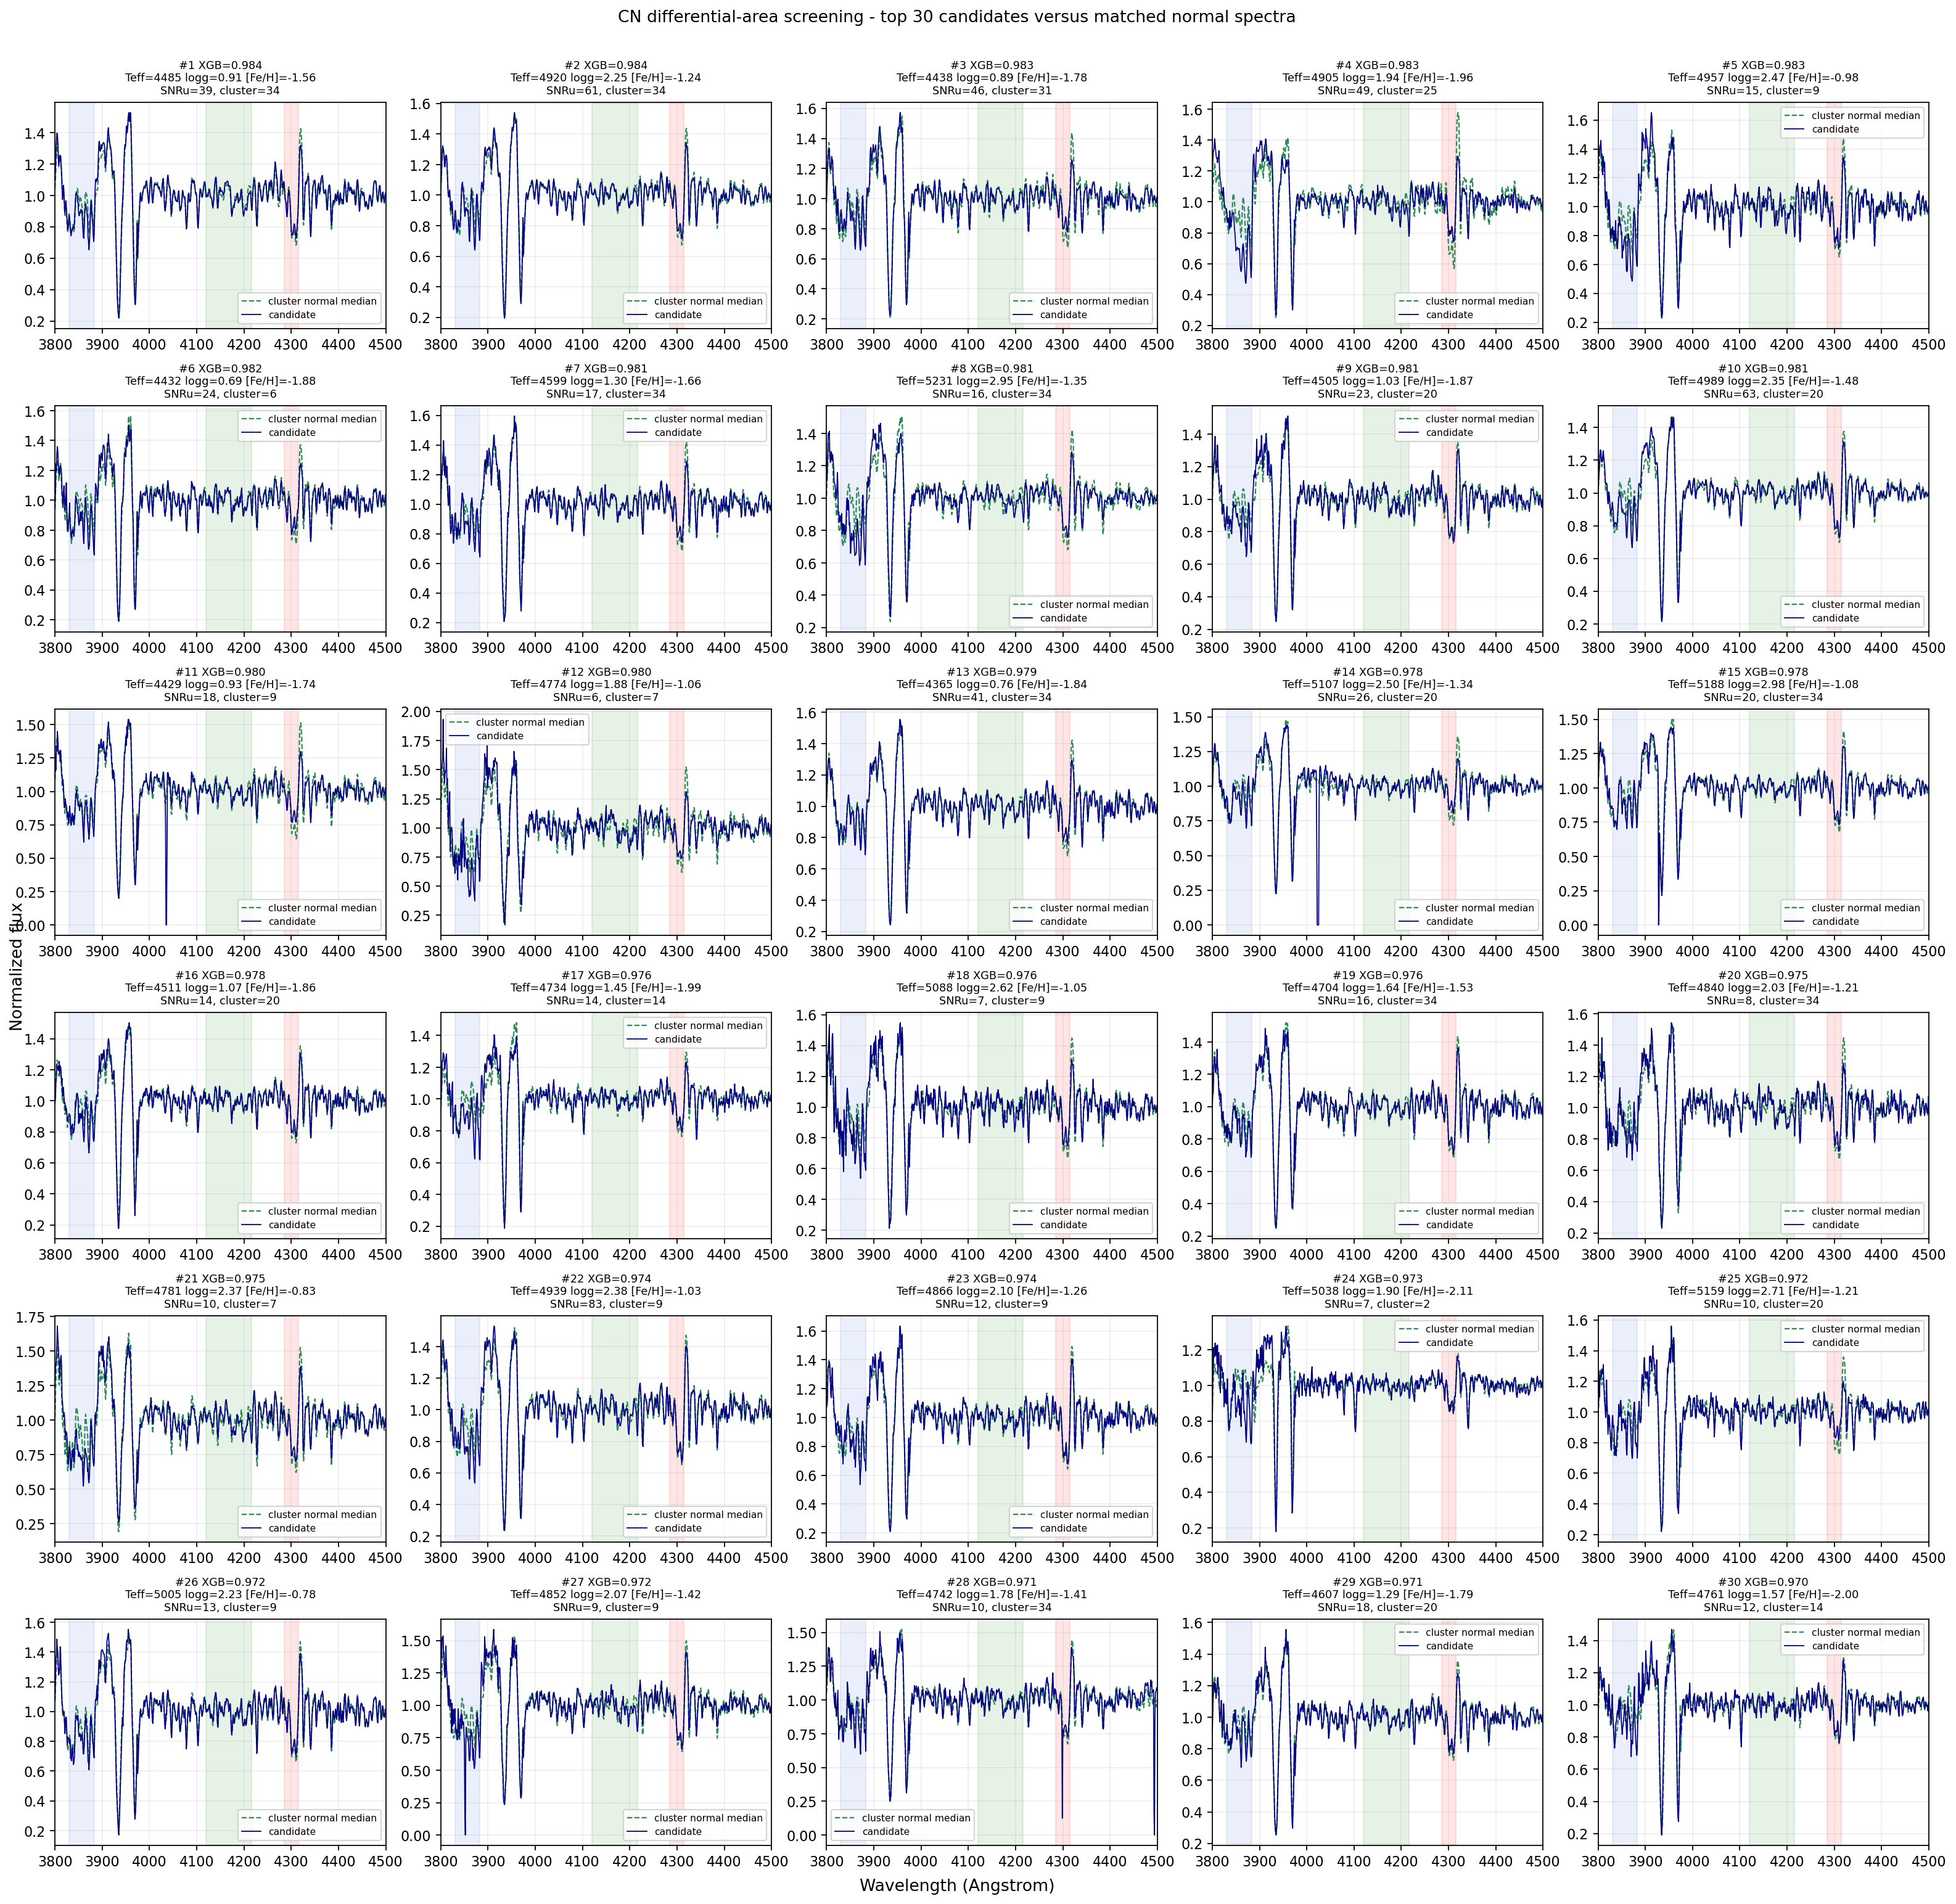

In [8]:
display(Image(filename=str(res["paths"]["plot"]), width=1100))